In [2]:
# !python.exe -m pip install --upgrade pip
# !pip install pandas
# !pip install scikit-learn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

ecp_csv = pd.read_csv('C:/Users/chris/Desktop/ml and py/atomikh/PJME_hourly.csv')
print (ecp_csv.head())
print ('='*50)
#a1 descriptive statistical analysis
print(f"Mean: {ecp_csv["PJME_MW"].mean().round(2)} \n"
      f"Median: {ecp_csv["PJME_MW"].median()} \n"
      f"Standard deviation: {ecp_csv["PJME_MW"].std().round(2)}\n"
      f"Min:{ecp_csv["PJME_MW"].min()} Max:{ecp_csv["PJME_MW"].max()}\n"
#a2 range
      f"Range of EC (max - min): {ecp_csv["PJME_MW"].max()-ecp_csv["PJME_MW"].min()}\n")


              Datetime  PJME_MW
0  2002-12-31 01:00:00  26498.0
1  2002-12-31 02:00:00  25147.0
2  2002-12-31 03:00:00  24574.0
3  2002-12-31 04:00:00  24393.0
4  2002-12-31 05:00:00  24860.0
Mean: 32080.22 
Median: 31421.0 
Standard deviation: 6464.01
Min:14544.0 Max:62009.0
Range of EC (max - min): 47465.0



In [4]:
#NΑs
print(f"NaNs in the dataset: \n{ecp_csv.isna().sum()}")

NaNs in the dataset: 
Datetime    0
PJME_MW     0
dtype: int64


3342.0
59881.0
Lower quantile: 27573.0
Upper quantile: 35650.0
Datetime    27
PJME_MW     27
dtype: int64


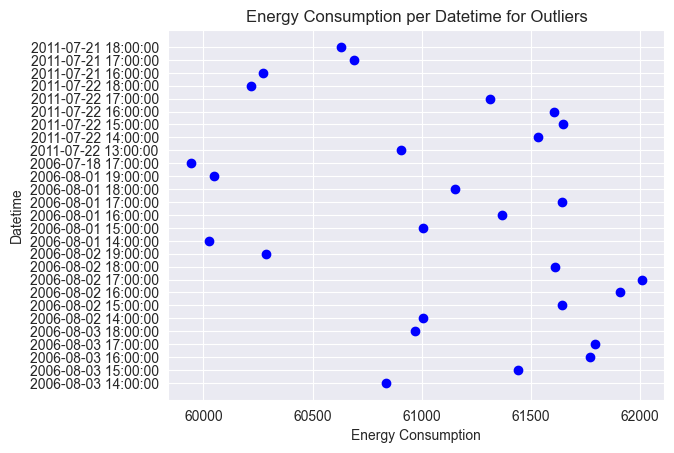

In [5]:
#Outliers
q1 = ecp_csv["PJME_MW"].quantile(0.25)
q3 = ecp_csv["PJME_MW"].quantile(0.75)
IQR = q3 - q1
lower = q1 - 3 * IQR
upper = q3 + 3 * IQR
print(f"{lower}\n{upper}")
outliers = ecp_csv[(ecp_csv["PJME_MW"] < lower) | (ecp_csv["PJME_MW"] > upper)]
print (f"Lower quantile: {q1}\nUpper quantile: {q3}")
print(f"{outliers.count()}")

plt.scatter(outliers["PJME_MW"], outliers["Datetime"], color='blue', marker='o')
plt.xlabel('Energy Consumption')
plt.ylabel('Datetime')
plt.title('Energy Consumption per Datetime for Outliers')
plt.show()

In [6]:
#time series
ecp_csv["Datetime"] = pd.to_datetime(ecp_csv["Datetime"], format="%Y-%m-%d %H:%M:%S")
ecp_csv["hour"] = ecp_csv["Datetime"].dt.hour
ecp_csv["day"] = ecp_csv["Datetime"].dt.day
ecp_csv["month"] = ecp_csv["Datetime"].dt.month
ecp_csv["year"] = ecp_csv["Datetime"].dt.year
ecp_csv["day_name"] = ecp_csv["Datetime"].dt.strftime('%a') #onoma meras
print(ecp_csv)


                  Datetime  PJME_MW  hour  day  month  year day_name
0      2002-12-31 01:00:00  26498.0     1   31     12  2002      Tue
1      2002-12-31 02:00:00  25147.0     2   31     12  2002      Tue
2      2002-12-31 03:00:00  24574.0     3   31     12  2002      Tue
3      2002-12-31 04:00:00  24393.0     4   31     12  2002      Tue
4      2002-12-31 05:00:00  24860.0     5   31     12  2002      Tue
...                    ...      ...   ...  ...    ...   ...      ...
145361 2018-01-01 20:00:00  44284.0    20    1      1  2018      Mon
145362 2018-01-01 21:00:00  43751.0    21    1      1  2018      Mon
145363 2018-01-01 22:00:00  42402.0    22    1      1  2018      Mon
145364 2018-01-01 23:00:00  40164.0    23    1      1  2018      Mon
145365 2018-01-02 00:00:00  38608.0     0    2      1  2018      Tue

[145366 rows x 7 columns]


<Axes: xlabel='hour'>

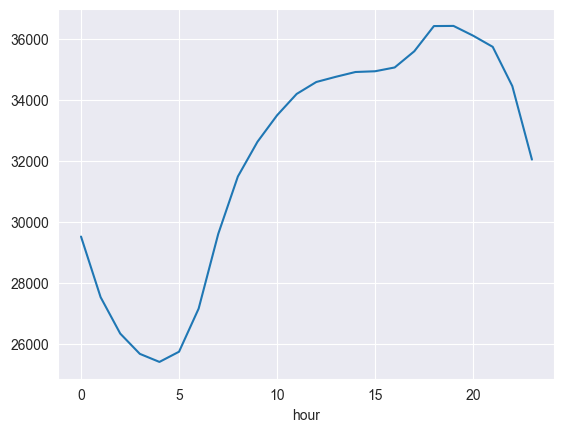

In [7]:
#time series chart by hours
ecp_csv.groupby("hour")["PJME_MW"].mean().plot(kind='line')

<Axes: xlabel='day'>

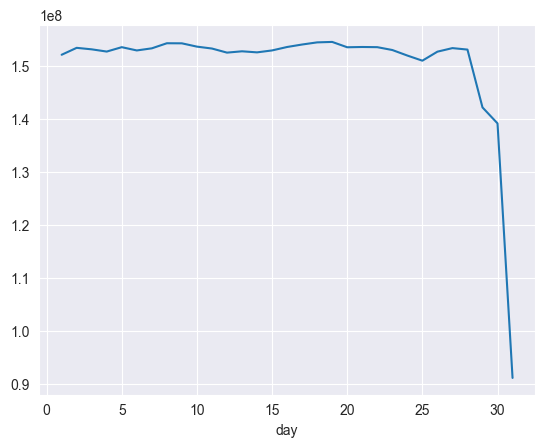

In [8]:
#time series chart by days
ecp_csv.groupby("day")["PJME_MW"].sum().plot(kind='line')

<Axes: xlabel='day_name'>

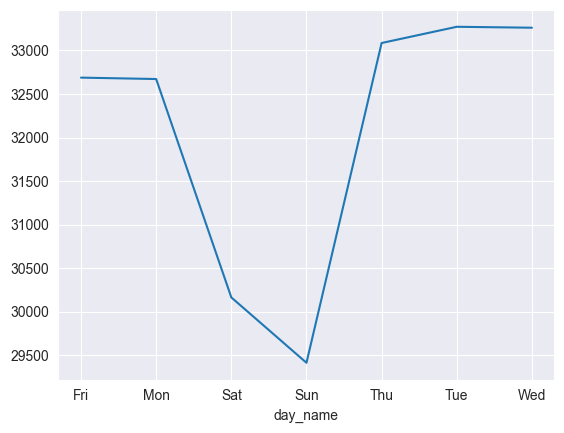

In [9]:
#time series chart by days of the week
ecp_csv.groupby("day_name")["PJME_MW"].mean().plot(kind='line')

In [10]:
y18 = ecp_csv[ecp_csv["Datetime"].dt.year == 2018]
y15= ecp_csv[ecp_csv["Datetime"].dt.year == 2015]
print (y18.count())
print("="*50)
print(y18["month"].max())
print(y15["month"].max())
print("="*50)
print (y15.count())
# d31.groupby("year")["PJME_MW"].sum().plot(kind='line')

Datetime    5136
PJME_MW     5136
hour        5136
day         5136
month       5136
year        5136
day_name    5136
dtype: int64
8
12
Datetime    8760
PJME_MW     8760
hour        8760
day         8760
month       8760
year        8760
day_name    8760
dtype: int64


<Axes: xlabel='month'>

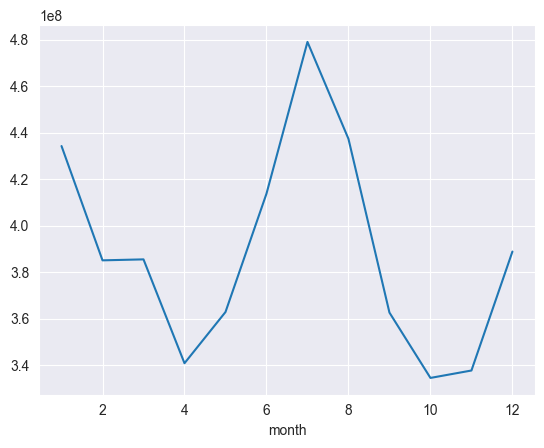

In [11]:
ecp_csv.groupby("month")["PJME_MW"].sum().plot(kind='line')

In [12]:
def sw_weekend_weekday_splitter (data):

    w_months = [11,12,1,2,3,4]
    s_months = [5,6,7,8,9]

    winters_of_2010 = data[(ecp_csv["Datetime"].dt.year == 2010) & ecp_csv["month"].isin(w_months)]
    summer_of_2010 = data[(ecp_csv["Datetime"].dt.year == 2010) & ecp_csv["month"].isin(s_months)]

    winter_weekends = winters_of_2010[winters_of_2010["Datetime"].dt.dayofweek >= 5]
    summer_weekends = summer_of_2010[summer_of_2010["Datetime"].dt.dayofweek >= 5]

    winter_weekdays = winters_of_2010[winters_of_2010["Datetime"].dt.dayofweek < 5]
    summer_weekdays = summer_of_2010[summer_of_2010["Datetime"].dt.dayofweek < 5]
    print("Winter weekends: ")
    print(winter_weekends)
    print("Winter weekdays: ")
    print(winter_weekdays)
    print("Summer weekends: ")
    print(summer_weekends)
    print("Summer weekdays: ")
    print(summer_weekdays)
    return winter_weekends,winter_weekdays,summer_weekends,summer_weekdays

winter_weekends,winter_weekdays,summer_weekends,summer_weekdays = sw_weekend_weekday_splitter(ecp_csv)

Winter weekends: 
                 Datetime  PJME_MW  hour  day  month  year day_name
70232 2010-12-26 01:00:00  29288.0     1   26     12  2010      Sun
70233 2010-12-26 02:00:00  28246.0     2   26     12  2010      Sun
70234 2010-12-26 03:00:00  27828.0     3   26     12  2010      Sun
70235 2010-12-26 04:00:00  27733.0     4   26     12  2010      Sun
70236 2010-12-26 05:00:00  27970.0     5   26     12  2010      Sun
...                   ...      ...   ...  ...    ...   ...      ...
78841 2010-01-02 21:00:00  41096.0    21    2      1  2010      Sat
78842 2010-01-02 22:00:00  40243.0    22    2      1  2010      Sat
78843 2010-01-02 23:00:00  38658.0    23    2      1  2010      Sat
78844 2010-01-03 00:00:00  36811.0     0    3      1  2010      Sun
78868 2010-01-02 00:00:00  31355.0     0    2      1  2010      Sat

[1198 rows x 7 columns]
Winter weekdays: 
                 Datetime  PJME_MW  hour  day  month  year day_name
61377 2010-01-01 00:00:00  31647.0     0    1      1  2

<Axes: xlabel='hour', ylabel='Average Energy Consumption'>

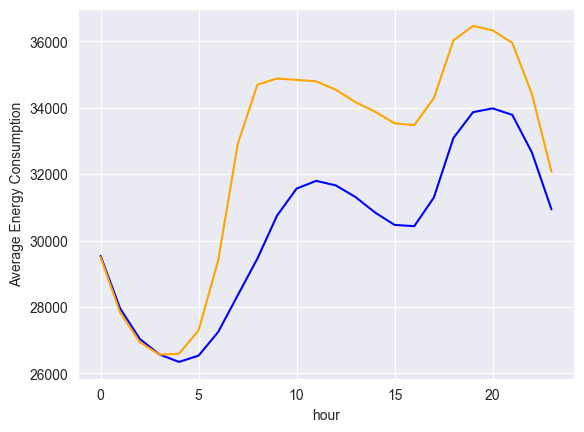

In [13]:
#Winter weekends vs winter weekdays
winter_weekends.groupby("hour")["PJME_MW"].mean().plot(kind='line',color='blue',ylabel='Average Energy Consumption')
winter_weekdays.groupby("hour")["PJME_MW"].mean().plot(kind='line',color='orange')

<Axes: xlabel='hour', ylabel='Average Energy Consumption'>

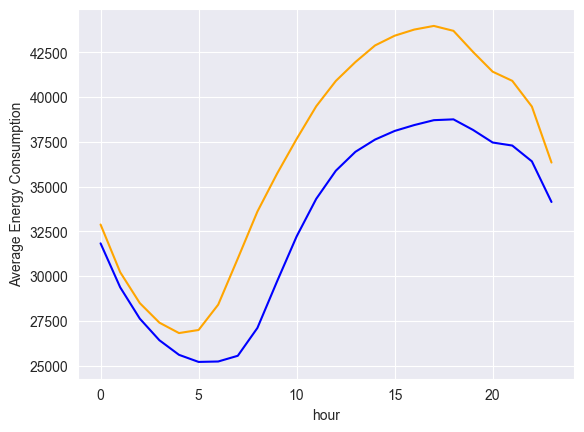

In [14]:
#Summer weekends vs Summer weekdays
summer_weekends.groupby("hour")["PJME_MW"].mean().plot(kind='line',color='blue',ylabel='Average Energy Consumption')
summer_weekdays.groupby("hour")["PJME_MW"].mean().plot(kind='line',color='orange')

<Axes: xlabel='hour', ylabel='Average Energy Consumption'>

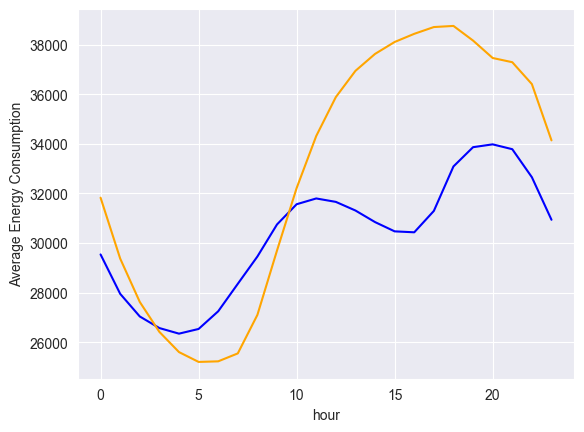

In [15]:
#Winter weekends vs Summer weekends
winter_weekends.groupby("hour")["PJME_MW"].mean().plot(kind='line',color='blue',ylabel='Average Energy Consumption')
summer_weekends.groupby("hour")["PJME_MW"].mean().plot(kind='line',color='orange')

<Axes: xlabel='hour', ylabel='Average Energy Consumption'>

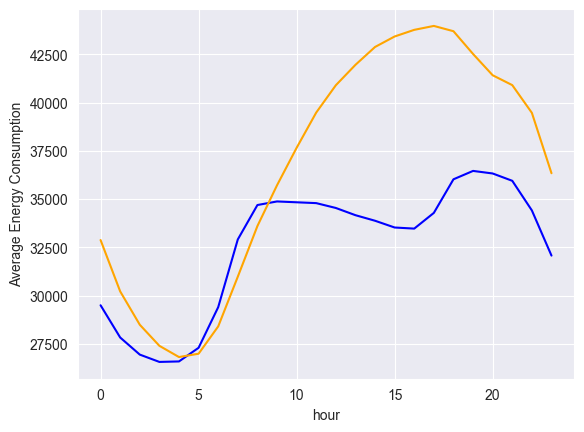

In [16]:
#Winter weekends vs Summer weekends
winter_weekdays.groupby("hour")["PJME_MW"].mean().plot(kind='line', color='blue', ylabel='Average Energy Consumption')
summer_weekdays.groupby("hour")["PJME_MW"].mean().plot(kind='line', color='orange')

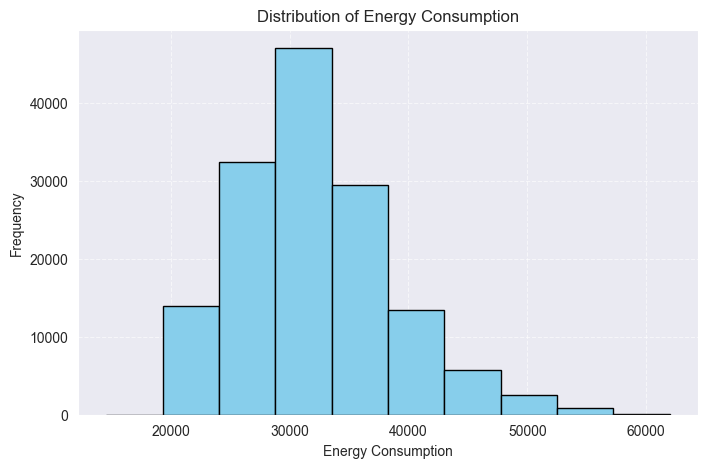

In [17]:
#Histogram for general distribution

plt.figure(figsize=(8,5))
plt.hist(ecp_csv['PJME_MW'], bins=10, color="skyblue", edgecolor="black")
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

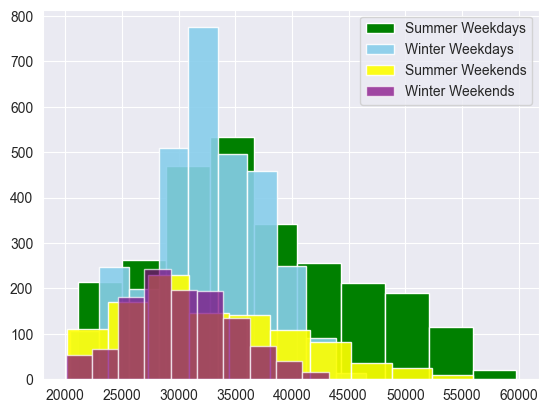

In [18]:
#Histogram for summer/winter weekdays/weekends
plt.hist(summer_weekdays['PJME_MW'], bins=10, alpha=1, label="Summer Weekdays", color="green")
plt.hist(winter_weekdays['PJME_MW'], bins=10, alpha=0.9, label="Winter Weekdays", color="skyblue")
plt.hist(summer_weekends['PJME_MW'], bins=10, alpha=0.9, label="Summer Weekends", color="yellow")
plt.hist(winter_weekends['PJME_MW'], bins=10, alpha=0.7, label="Winter Weekends", color="purple")
plt.legend()
plt.show()

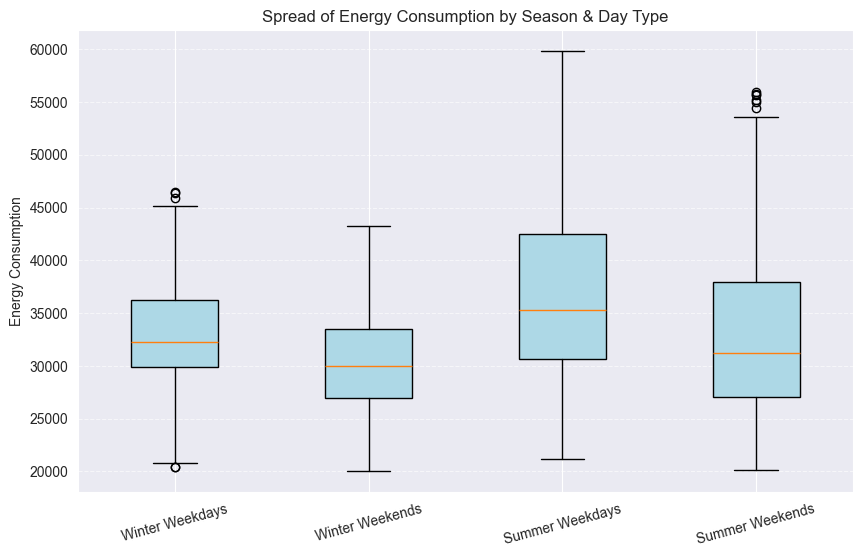

In [19]:
#boxplots for energy consumption

data = [
    winter_weekdays['PJME_MW'],
    winter_weekends['PJME_MW'],
    summer_weekdays['PJME_MW'],
    summer_weekends['PJME_MW']
]

labels = ["Winter Weekdays", "Winter Weekends", "Summer Weekdays", "Summer Weekends"]

plt.figure(figsize=(10, 6))
plt.boxplot(data, patch_artist=True,
            boxprops=dict(facecolor="lightblue"))
plt.xticks(range(1, len(labels) + 1), labels, rotation=15)
plt.title("Spread of Energy Consumption by Season & Day Type")
plt.ylabel("Energy Consumption")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.show()

In [20]:
from sklearn.cluster import KMeans
def elbow_method(data):
    inertia = []
    K_range = range(1, 11)  # test k from 1 to 10

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertia.append(kmeans.inertia_)
    plt.figure(figsize=(8, 5))
    plt.plot(K_range, inertia, marker='o')
    plt.title("Elbow Method for Optimal k")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
    plt.grid(True)
    plt.show()



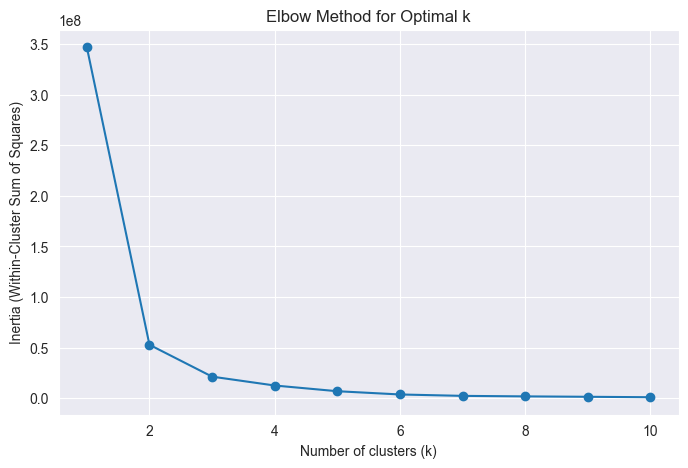

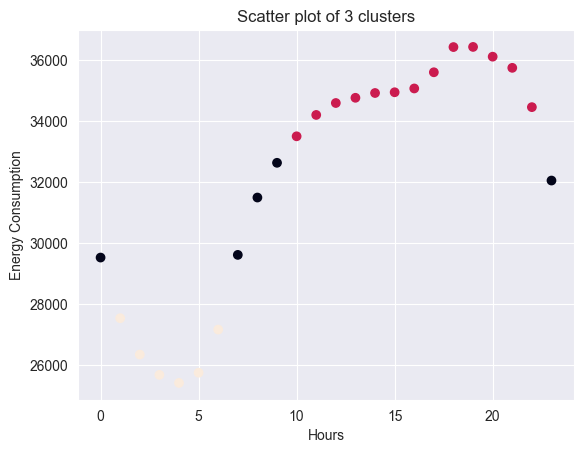

In [27]:
#clustering consumption energy, grouping by hours
hourly_data = ecp_csv.groupby(ecp_csv['Datetime'].dt.hour)['PJME_MW'].mean().reset_index()
hourly_data.columns = ['hour', 'avg_energy']
x=hourly_data


# Plot elbow curve
elbow_method(x)
#based on the graph, 3 is the elbow point
K = 3

model = KMeans(n_clusters=K, random_state=42)
model.fit(x)
plt.scatter(x["hour"],x["avg_energy"], c=model.labels_)
plt.title("Scatter plot of 3 clusters")
plt.xlabel("Hours")
plt.ylabel("Energy Consumption")
plt.show()


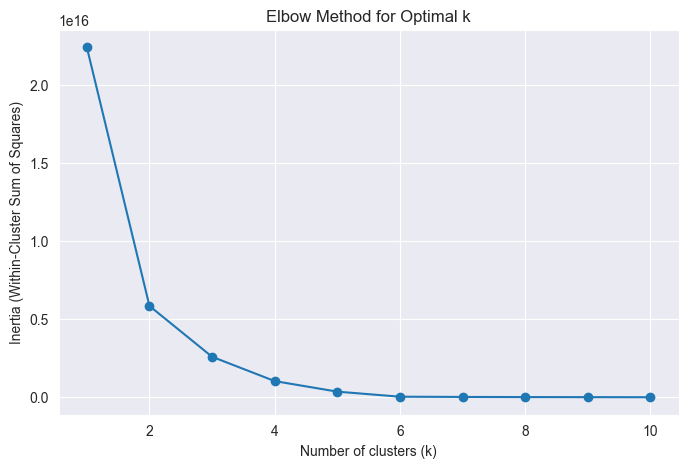

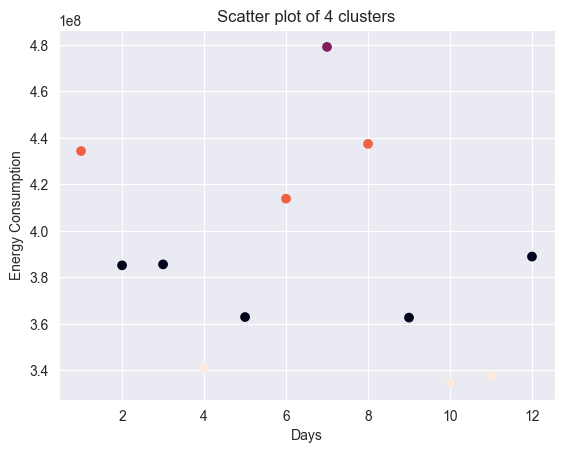

In [28]:
#clustering consumption energy, grouping by months

month_data = ecp_csv.groupby(ecp_csv['Datetime'].dt.month)['PJME_MW'].sum().reset_index()
month_data.columns = ['month', 'avg_energy']
x=month_data


# Plot elbow curve
elbow_method(x)
#based on the graph, 3 is the elbow point
K = 4

model = KMeans(n_clusters=K, random_state=42)
model.fit(x)
plt.scatter(x["month"],x["avg_energy"], c=model.labels_)
plt.title("Scatter plot of 4 clusters")
plt.xlabel("Days")
plt.ylabel("Energy Consumption")
plt.show()


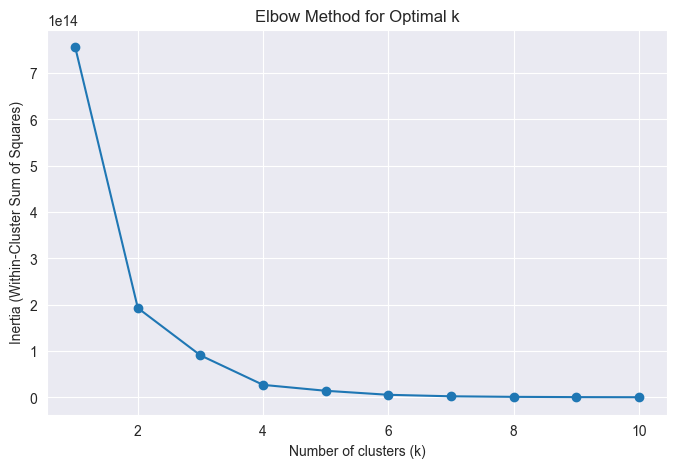

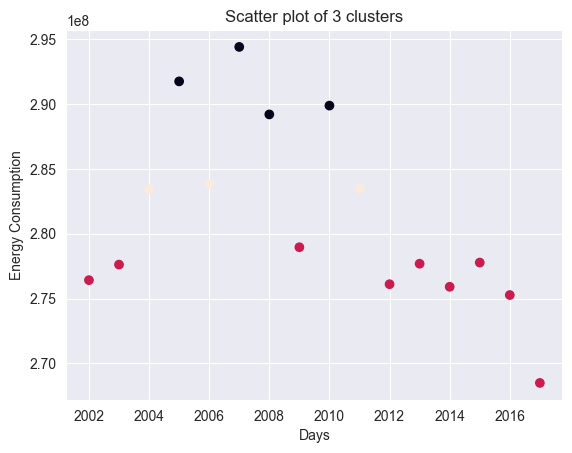

In [29]:
#clustering consumption energy, grouping by years (minus 2018 which is incomplete)

year_data = ecp_csv.groupby(ecp_csv['Datetime'].dt.year)['PJME_MW'].sum().reset_index()
year_data.columns = ['year', 'avg_energy']
x=year_data[year_data['year']<2018]


# Plot elbow curve
elbow_method(x)
#based on the graph, 3 is the elbow point
K = 3

model = KMeans(n_clusters=K, random_state=42)
model.fit(x)
plt.scatter(x["year"],x["avg_energy"], c=model.labels_)
plt.title("Scatter plot of 3 clusters")
plt.xlabel("Days")
plt.ylabel("Energy Consumption")
plt.show()
